# Variante GRU — Santiago Diaz

Entrenamiento del `CharRNN(cell_type='gru')` para generar nombres de dinosaurios.

Reutiliza el núcleo compartido en [src/](../src/): `dataset.py`, `model.py`, `train.py`, `sample.py`.

**Hiperparámetros**: `embed_dim=32`, `hidden_dim=128`, `num_layers=1`, `lr=1e-3`, `batch_size=64`, `patience=5`.

Ejecuta este notebook desde la **raíz del repo** (no desde `notebooks/`) para que los imports relativos funcionen.

In [1]:
import sys, os
from pathlib import Path

REPO_ROOT = Path.cwd()
while REPO_ROOT.name and not (REPO_ROOT / 'CLAUDE.md').exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
print('cwd:', os.getcwd())

cwd: /home/ec2-user/SageMaker


In [2]:
import math
import itertools
import csv
import torch
import matplotlib.pyplot as plt
from Parte_1_Generador_Caracteres.src.dataset import make_dataloaders, load_names
from Parte_1_Generador_Caracteres.src.model import CharRNN
from Parte_1_Generador_Caracteres.src.sample import load_model, generate_unique

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


device: cpu


## 1. Datos

In [3]:
names = load_names('data/dinos.csv')
print(f'total nombres: {len(names)}')
print(f'longitud min/max: {min(map(len, names))}/{max(map(len, names))}')
print('ejemplos:', names[:5])

total nombres: 1536
longitud min/max: 3/26
ejemplos: ['aachenosaurus', 'aardonyx', 'abdallahsaurus', 'abelisaurus', 'abrictosaurus']


In [4]:
train_loader, val_loader, vocab, max_len = make_dataloaders('data/dinos.csv', batch_size=64)
print(f'vocab_size={len(vocab)}, max_len={max_len}')
print(f'train batches={len(train_loader)}, val batches={len(val_loader)}')

vocab_size=29, max_len=28
train batches=22, val batches=3


## 2. Entrenamiento

In [5]:
from argparse import Namespace
from Parte_1_Generador_Caracteres.src.train import train

args = Namespace(
    data='data/dinos.csv',
    cell='gru',
    epochs=50,
    batch_size=64,
    embed=32,
    hidden=128,
    layers=1,
    lr=1e-3,
    patience=5,
    checkpoint='Parte_1_Generador_Caracteres/models/gru_SantiagoDiaz.pt',
    run_tag='SantiagoDiaz',
)
history, best_val = train(args)
print(f'\nbest val loss: {best_val:.4f}  ppl={math.exp(best_val):.2f}')

[train] device=cpu, cell=gru


/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


epoch 01 | train 3.0221 | val 2.5572
epoch 02 | train 2.4230 | val 2.2047
epoch 03 | train 2.1602 | val 2.0234
epoch 04 | train 2.0235 | val 1.9199
epoch 05 | train 1.9477 | val 1.8497
epoch 06 | train 1.8952 | val 1.8019
epoch 07 | train 1.8509 | val 1.7627
epoch 08 | train 1.8154 | val 1.7355
epoch 09 | train 1.7840 | val 1.7116
epoch 10 | train 1.7563 | val 1.6883
epoch 11 | train 1.7302 | val 1.6623
epoch 12 | train 1.7069 | val 1.6413
epoch 13 | train 1.6851 | val 1.6225
epoch 14 | train 1.6646 | val 1.6055
epoch 15 | train 1.6444 | val 1.5914
epoch 16 | train 1.6262 | val 1.5791
epoch 17 | train 1.6098 | val 1.5669
epoch 18 | train 1.5930 | val 1.5561
epoch 19 | train 1.5773 | val 1.5441
epoch 20 | train 1.5611 | val 1.5360
epoch 21 | train 1.5461 | val 1.5350
epoch 22 | train 1.5310 | val 1.5220
epoch 23 | train 1.5158 | val 1.5156
epoch 24 | train 1.5014 | val 1.5125
epoch 25 | train 1.4894 | val 1.5080
epoch 26 | train 1.4764 | val 1.4967
epoch 27 | train 1.4620 | val 1.4975
e

## 3. Curvas de aprendizaje

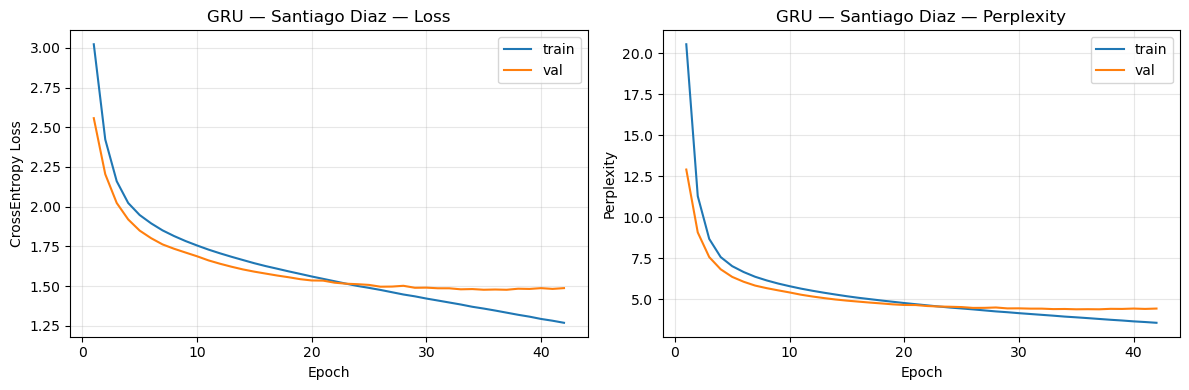

Guardado en reports/learning_curves_gru.png


In [6]:
epochs_ran = list(range(1, len(history['train_loss']) + 1))
train_ppl = [math.exp(l) for l in history['train_loss']]
val_ppl   = [math.exp(l) for l in history['val_loss']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_ran, history['train_loss'], label='train')
axes[0].plot(epochs_ran, history['val_loss'],   label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CrossEntropy Loss')
axes[0].set_title('GRU — Santiago Diaz — Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, train_ppl, label='train')
axes[1].plot(epochs_ran, val_ppl,   label='val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].set_title('GRU — Santiago Diaz — Perplexity')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig('reports/learning_curves_gru.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado en reports/learning_curves_gru.png')

## 4. Métricas finales

In [7]:
best_train = min(history['train_loss'])
print(f'Épocas entrenadas : {len(epochs_ran)}')
print(f'Mejor train loss  : {best_train:.4f}  (ppl = {math.exp(best_train):.2f})')
print(f'Mejor val loss    : {best_val:.4f}  (ppl = {math.exp(best_val):.2f})')

Épocas entrenadas : 42
Mejor train loss  : 1.2696  (ppl = 3.56)
Mejor val loss    : 1.4774  (ppl = 4.38)


## 5. Muestreo — 5 nombres

In [8]:
model_gru, vocab_gru, max_len_gru = load_model(args.checkpoint, device=device)
seen = set(load_names('data/dinos.csv'))

sample_names = generate_unique(
    model_gru, vocab_gru, max_len_gru,
    n=5, temperature=1.0, top_k=None, top_p=0.9,
    seen=seen, device=device,
)
print('5 nombres generados por la GRU (temperature=1.0, top_p=0.9):')
for name in sample_names:
    print(f'  → {name}')

5 nombres generados por la GRU (temperature=1.0, top_p=0.9):
  → hengalivenia
  → eudusitisaurus
  → dalodon
  → eoplonykus
  → drosinops


## 6. Barrido de parámetros de muestreo

In [9]:
temperatures = [0.7, 1.0, 2.5, 4.0]
top_ks       = [None, 5, 10]
top_ps       = [None, 0.9, 0.95]

rows = []
for temp, tk, tp in itertools.product(temperatures, top_ks, top_ps):
    batch = generate_unique(
        model_gru, vocab_gru, max_len_gru,
        n=3, temperature=temp, top_k=tk, top_p=tp,
        seen=seen, device=device,
    )
    for name in batch:
        rows.append({'temperature': temp, 'top_k': tk, 'top_p': tp, 'name': name})

out_path = Path('data/generated/names_gru.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['temperature', 'top_k', 'top_p', 'name'])
    writer.writeheader()
    writer.writerows(rows)
print(f'Guardados {len(rows)} nombres en {out_path}')

Guardados 108 nombres en data/generated/names_gru.csv


## 7. Promoción a `best_model.pt` (si gana)

Comparar `best_val` con el de Alan (RNN) y Juan Camilo (LSTM). Si esta GRU es la mejor, correr la celda de abajo.

In [10]:
import shutil

# Solo ejecutar si la GRU tiene el menor val loss de los tres modelos
# shutil.copy(args.checkpoint, 'Parte_1_Generador_Caracteres/models/best_model.pt')
# print('GRU promovida a best_model.pt')

print(f'GRU val loss: {best_val:.4f}  (ppl={math.exp(best_val):.2f})')
print('Descomentar las líneas de arriba solo si este valor es menor que RNN y LSTM.')

GRU val loss: 1.4774  (ppl=4.38)
Descomentar las líneas de arriba solo si este valor es menor que RNN y LSTM.
